# Safety experiment plots, averaged over seeds

Loads every seed in `results_dir` saved for the chosen `regressor_name` and `n`
(files `simulations_safety_model{regressor_name}_{seed}_seed_n_{n}_martingales.pkl`, written by
`safety_simulations.py`). Each plot shows the mean across seeds; when there is more than one seed,
a shaded band shows ±1 standard deviation.

### Changelog
**2026-10-01: rewritten to average over seeds**
- Replaced the hard-coded absolute path for seed 1 with a glob over all seeds for the chosen `regressor_name` and `n`. The seed is parsed from the filename.
- Removed the `seed` / `single_seed` config and the unused, broken `load_martingales()` (it indexed `mean_martingales[strategy]` before creating it).
- Martingales, lambdas, Wasserstein distances and risk differences are stacked across seeds and plotted as mean ± 1 sd.
- **x-axis changed:** all plots now use the real time index t. Updates happen at `t = n_init + k·batch` (see `ML_e_process.martingales`). Previously, lambdas, Wasserstein distances and risk differences were plotted against `index × batch`, starting at 0. That shifted them left by `n_init` compared with the martingales.
- Added a dashed `1/alpha` rejection threshold to the martingale plot.
- Lambdas are still divided by 5 (`lambda_scale`), as in the original cell 5.
- Wasserstein distances are handled both as plain floats (current format) and as `(distance, reference)` pairs (the format the old cell 11 expected).
- Added a final 2×2 figure (martingales, lambdas, Wasserstein distance, risk difference), saved as a PDF next to the notebook.
- Removed the exploratory cells that only displayed raw objects (`all_martingales[2]`, `len(...)` prints).

**2026-10-06: wealth heatmap colors**
- Most average wealths are close to 1 (about 75% lie between 0.8 and 1.25), so the linear `viridis` scale showed them in nearly the same color. Both wealth heatmaps now use a `FuncNorm` that stretches the scale around 1: `sign(w - 1) * |w - 1| ** wealth_gamma` with `wealth_gamma = 0.5`. The 0.8–1.25 range now covers about half of the colormap instead of a quarter. The colormap and the vmin/vmax are unchanged, and the colorbar ticks are set explicitly. Set `wealth_gamma = 1` to get the old linear scale back.

**Rollback:** the original cells are copied verbatim in the appendix at the bottom of the notebook. You can also use `git diff` / `git checkout` on this file, but note that the notebook already had uncommitted changes before this rewrite.

In [12]:
from pathlib import Path
import pickle
import re

import matplotlib.pyplot as plt
from matplotlib.colors import FuncNorm
import numpy as np


alpha = 0.05
n = 20000#20000#15000#9000#5001#5000#2599#899#399#299#799#
regressor_name = "nn" #"tm" #"nn"
coordinate = 0
batch_list = [5, 10, 20]
smallest_batch = min(batch_list)
strategy = "coin_betting"#"sign" # #"coin_betting"#
pretraining_percentage = 1          # must match --pretraining_percentage used in safety_simulations.py
n_init = int(n * pretraining_percentage / 100.0)
lambda_scale = 5.0                   # lambdas are divided by this (as in the original notebook)

results_dir = Path("../../results/csv/safety_simulations")

In [13]:
def load_runs():
    """Load every seed for (regressor_name, n). Returns {seed: (martingales, lambdas, distances, errors)}."""
    pattern = re.compile(
        rf"simulations_safety_model_{re.escape(regressor_name)}_(\d+)_seed_n_{n}_strategy_{re.escape(strategy)}_martingales\.pkl"
    )
    runs = {}
    for file in results_dir.iterdir():
        match = pattern.fullmatch(file.name)
        if match:
            with open(file, "rb") as f:
                runs[int(match.group(1))] = pickle.load(f)
    if not runs:
        raise FileNotFoundError(f"No files for model={regressor_name}, n={n} in {results_dir.resolve()}")
    runs = dict(sorted(runs.items()))
    print(f"loaded {len(runs)} seed(s): {list(runs)}")
    return runs


def stack(sequences):
    """Stack per-seed sequences into an array (n_seeds, T, ...), truncating to the shortest one."""
    arrays = [np.asarray(s, dtype=float) for s in sequences]
    length = min(a.shape[0] for a in arrays)
    if any(a.shape[0] != length for a in arrays):
        print(f"warning: sequences have different lengths, truncating to {length}")
    return np.stack([a[:length] for a in arrays])


def best_params(s, b):
    """Older files store the list of selected parameters, newer ones a dict that also holds the wealth history."""
    entry = runs[s][1][coordinate][b][strategy]
    return entry["best_params"] if isinstance(entry, dict) else entry


runs = load_runs()
seeds = list(runs)

martingales = {
    b: stack([runs[s][0][strategy][b][coordinate] for s in seeds]) for b in batch_list
}
lambdas = {
    b: stack([[d["lambda"] / lambda_scale for d in best_params(s, b)] for s in seeds])
    for b in batch_list
}
distances = stack([runs[s][2] for s in seeds])   # (n_seeds, T) or (n_seeds, T, 2) with a reference column
risk_diffs = stack([runs[s][3] for s in seeds])


def update_times(length, batch):
    """Time index of the k-th update for a given batch size: n_init + (k + 1) * batch."""
    return n_init + batch * np.arange(1, length + 1)

loaded 50 seed(s): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


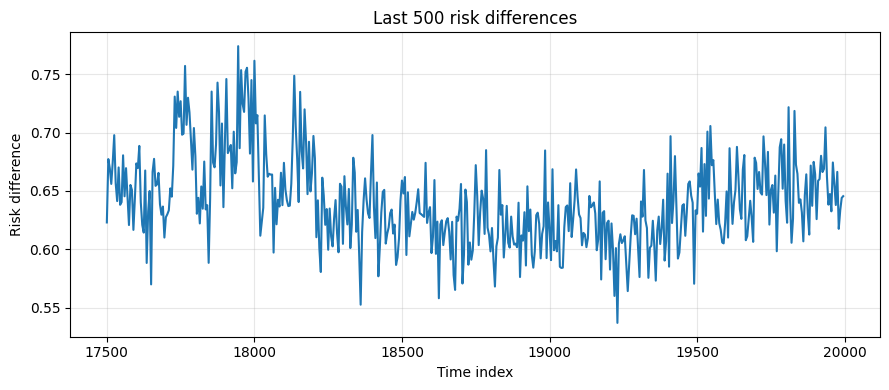

In [14]:
vals = risk_diffs[0][-500:]
t = update_times(len(risk_diffs[0]), smallest_batch)[-500:]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, vals)
ax.set(xlabel="Time index", ylabel="Risk difference", title="Last 500 risk differences")
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [15]:
def plot_mean_band(ax, t, values, nstd=0.5, label=None, **kwargs):
    """Plot the mean over seeds (axis 0) and a ±1 sd band when there are several seeds."""
    mean = values.mean(axis=0)
    line, = ax.plot(t, mean, label=label, **kwargs)
    if values.shape[0] > 1:
        sd = values.std(axis=0)
        ax.fill_between(t, mean - nstd*sd, mean + nstd*sd, color=line.get_color(), alpha=0.2, linewidth=0)


def seeds_note():
    return f"mean over {len(seeds)} seed(s)"


def plot_martingales(ax):
    for b in batch_list:
        values = martingales[b]
        plot_mean_band(ax, np.arange(values.shape[1]), values, label=f"batch size {b}")
    #ax.axhline(1 / alpha, color="gray", linestyle="--", linewidth=1, label=r"$1/\alpha$")
    ax.set(title=f"Coin betting martingales (feature {coordinate}, {seeds_note()})",
           xlabel="Time index", ylabel="Martingale value")
    ax.legend(title="Batch")
    ax.grid(True, alpha=0.3)


def plot_lambdas(ax):
    for b in batch_list:
        values = lambdas[b]
        plot_mean_band(ax, update_times(values.shape[1], b), values, label=f"batch size {b}")
    ax.set(title=f"Selected lambda by batch (feature {coordinate}, {seeds_note()})",
           xlabel="Time index", ylabel="Lambda value")
    ax.legend(title="Batch")
    ax.grid(True, alpha=0.3)


def plot_wasserstein(ax):
    t = update_times(distances.shape[1], smallest_batch)
    if distances.ndim == 3:  # (distance, reference) pairs
        plot_mean_band(ax, t, distances[:, :, 0], label="Wasserstein distance")
        plot_mean_band(ax, t, distances[:, :, 1], label="Reference")
        ax.legend()
    else:
        plot_mean_band(ax, t, distances)
    ax.set(title=f"Wasserstein distance, estimated vs. true conditional ({seeds_note()})",
           xlabel="Time index", ylabel="Distance")
    ax.grid(True, alpha=0.3)


def plot_risk_difference(ax):
    t = update_times(risk_diffs.shape[1], smallest_batch)
    plot_mean_band(ax, t, risk_diffs)
    ax.set(title=rf"Risk difference $\hat m$ vs. $m_0$ ({seeds_note()})",
           xlabel="Time index", ylabel="Test risk difference")
    ax.grid(True, alpha=0.3)

## Martingales

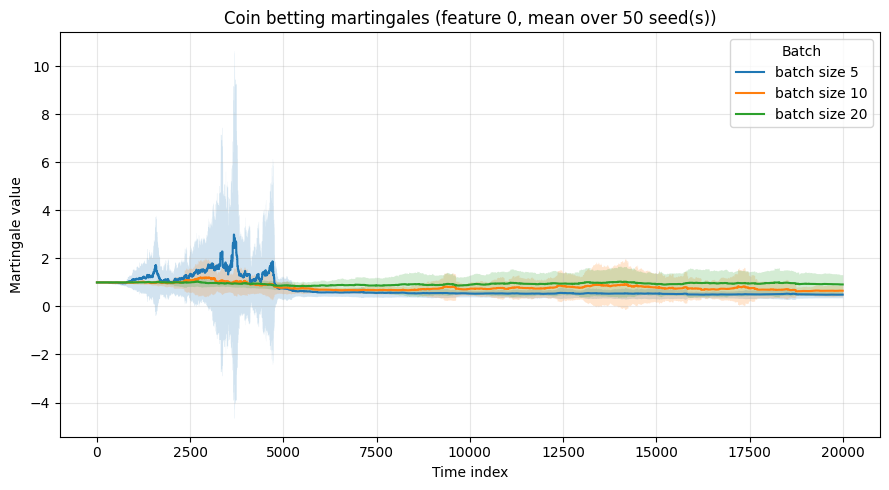

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_martingales(ax)
plt.tight_layout()

## Selected lambdas

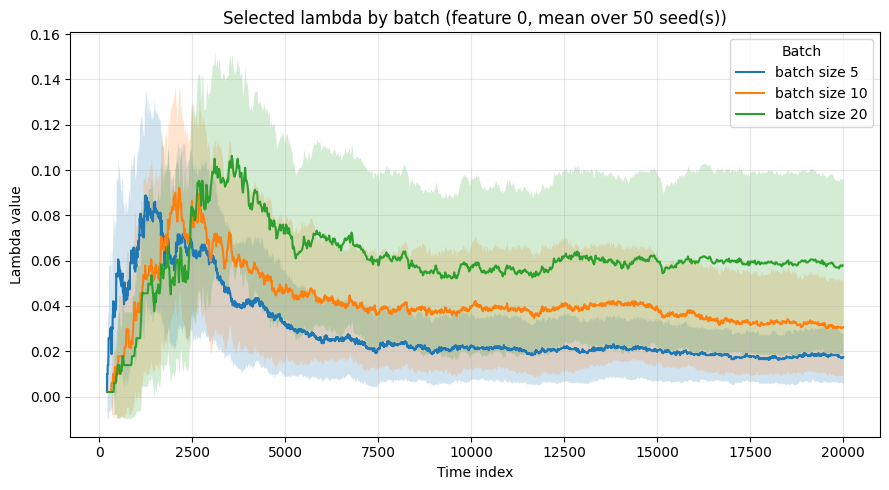

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_lambdas(ax)
plt.tight_layout()

## Wasserstein distance

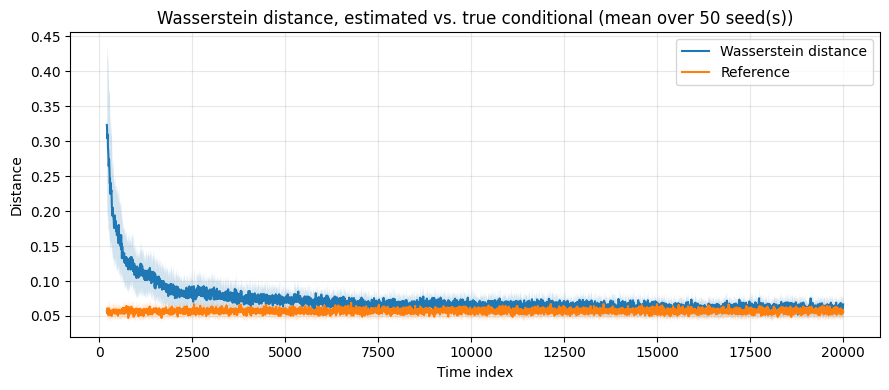

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_wasserstein(ax)
plt.tight_layout()

## Risk difference

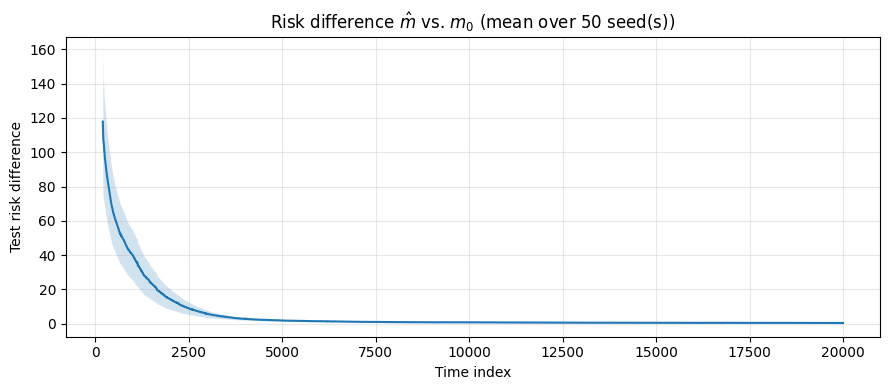

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_risk_difference(ax)
plt.tight_layout()

## Summary figure: martingales, lambdas, Wasserstein distance, risk difference

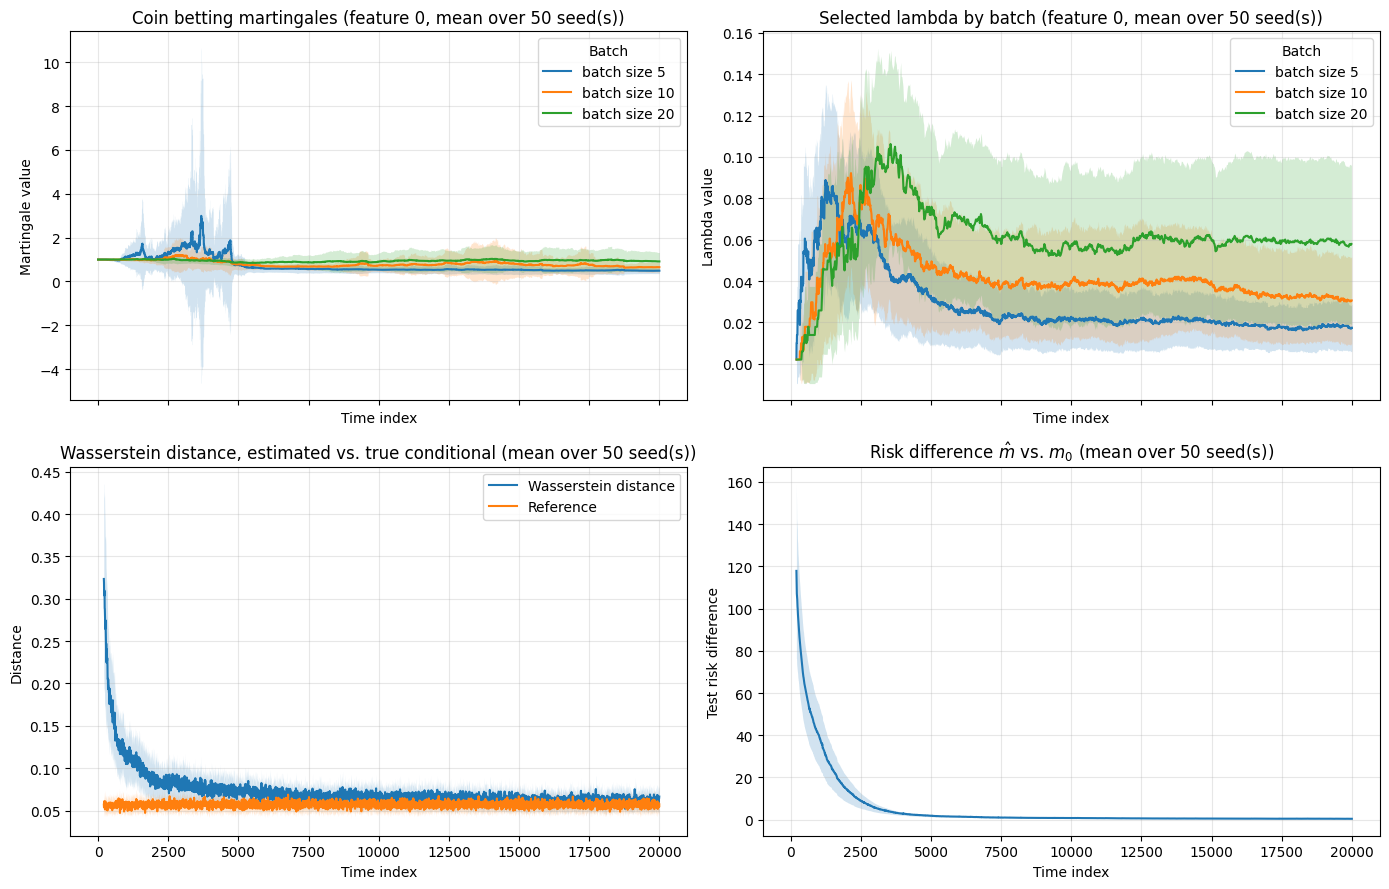

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
plot_martingales(axes[0, 0])
plot_lambdas(axes[0, 1])
plot_wasserstein(axes[1, 0])
plot_risk_difference(axes[1, 1])
plt.tight_layout()
fig.savefig(f"safety_summary_model{regressor_name}_n{n}.pdf", bbox_inches="tight")

## Wealth heatmap: average wealth per lambda and time interval

Each cell is the cumulative wealth of one lambda, averaged over the updates that fall in that time interval and over seeds. One square per batch size, with a shared color scale. Needs files saved after the `wealth_history` change in `BettingStrategy`.

Text(0.5, 0.98, 'Wealth per lambda (feature 0, mean over 50 seed(s))')

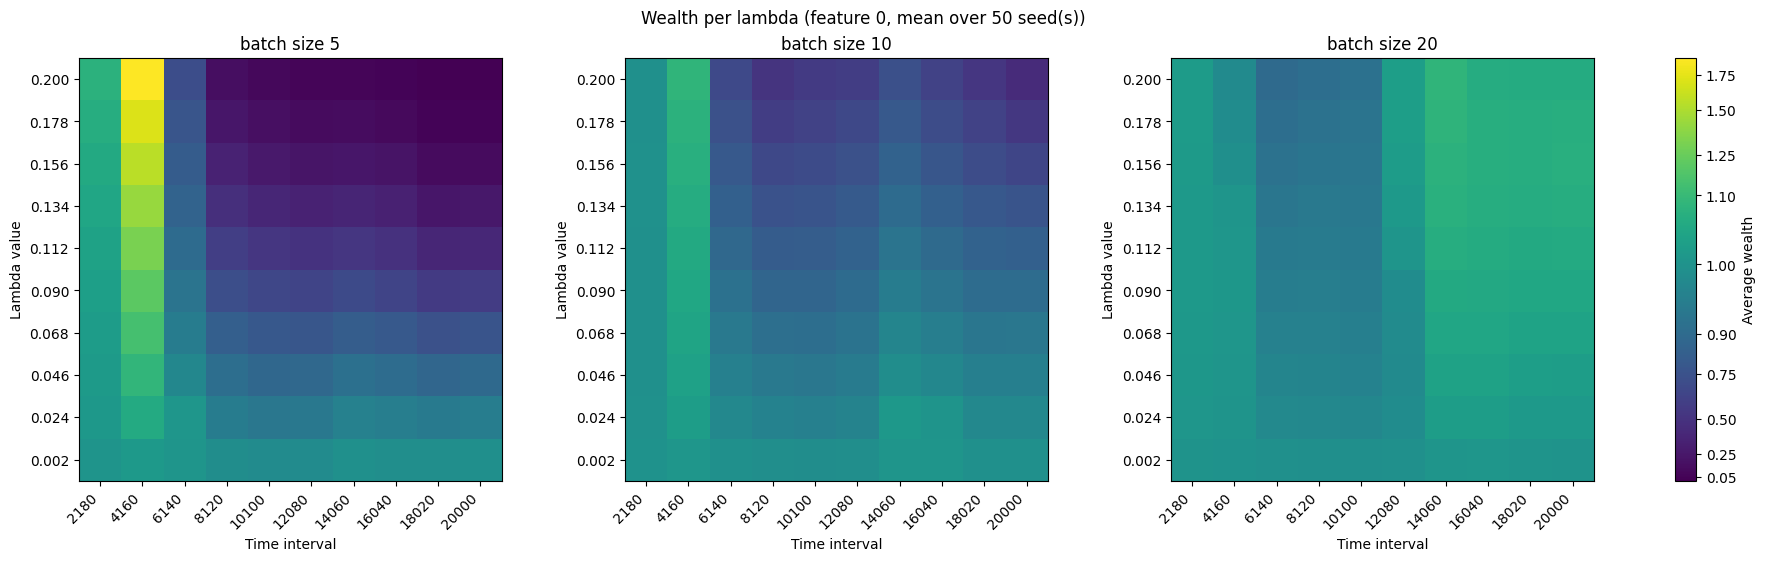

In [21]:
n_intervals = 10
lambda_values = np.linspace(0.01, 1, 10) / lambda_scale   # grid of prepare_lambda_parameters() in safety_simulations.py
edges = np.linspace(n_init, n, n_intervals + 1)

# Most average wealths sit close to 1, so a linear color scale shows them all in nearly the same color.
# This norm stretches the colors around 1 with sign(w - 1) * |w - 1| ** gamma (gamma = 1 is linear).
wealth_gamma = 0.5
wealth_ticks = [0.05, 0.25, 0.5, 0.75, 0.9, 1, 1.1, 1.25, 1.5, 1.75]


def wealth_norm(vmin, vmax, gamma=wealth_gamma):
    def forward(w):
        return np.sign(w - 1) * np.abs(w - 1) ** gamma

    def inverse(z):
        return 1 + np.sign(z) * np.abs(z) ** (1 / gamma)

    return FuncNorm((forward, inverse), vmin=vmin, vmax=vmax)


def colorbar_ticks(vmin, vmax):
    return [t for t in wealth_ticks if vmin <= t <= vmax]


def wealth_heatmap(b):
    """Average wealth over the updates in each interval and over seeds, shape (n_lambdas, n_intervals)."""
    wealths = stack([runs[s][1][coordinate][b][strategy]["wealth_history"] for s in seeds])  # (n_seeds, T, n_lambdas)
    interval = np.digitize(update_times(wealths.shape[1], b), edges[1:-1])
    return np.stack([wealths[:, interval == k].mean(axis=(0, 1)) for k in range(n_intervals)], axis=1)


heatmaps = {b: wealth_heatmap(b) for b in batch_list}
vmin = min(np.nanmin(h) for h in heatmaps.values())
vmax = max(np.nanmax(h) for h in heatmaps.values())

fig, axes = plt.subplots(1, len(batch_list), figsize=(6 * len(batch_list), 5.5), constrained_layout=True)
for ax, b in zip(axes, batch_list):
    im = ax.imshow(heatmaps[b], origin="lower", cmap="viridis", norm=wealth_norm(vmin, vmax))
    ax.set_xticks(range(n_intervals), [f"{hi:.0f}" for _, hi in zip(edges[:-1], edges[1:])], # {lo:.0f}–
                  rotation=45, ha="right")
    ax.set_yticks(range(len(lambda_values)), [f"{lam:.3f}" for lam in lambda_values])
    ax.set(title=f"batch size {b}", xlabel="Time interval", ylabel="Lambda value")
fig.colorbar(im, ax=axes, label="Average wealth", ticks=colorbar_ticks(vmin, vmax))
fig.suptitle(f"Wealth per lambda (feature {coordinate}, {seeds_note()})")

## Full summary figure: the four plots above and the wealth heatmaps

The heatmaps here split `[0, n]` into 10 equal intervals (instead of `[n_init, n]`). The martingale panel is zoomed to `martingale_ylim`, which can cut part of the band.

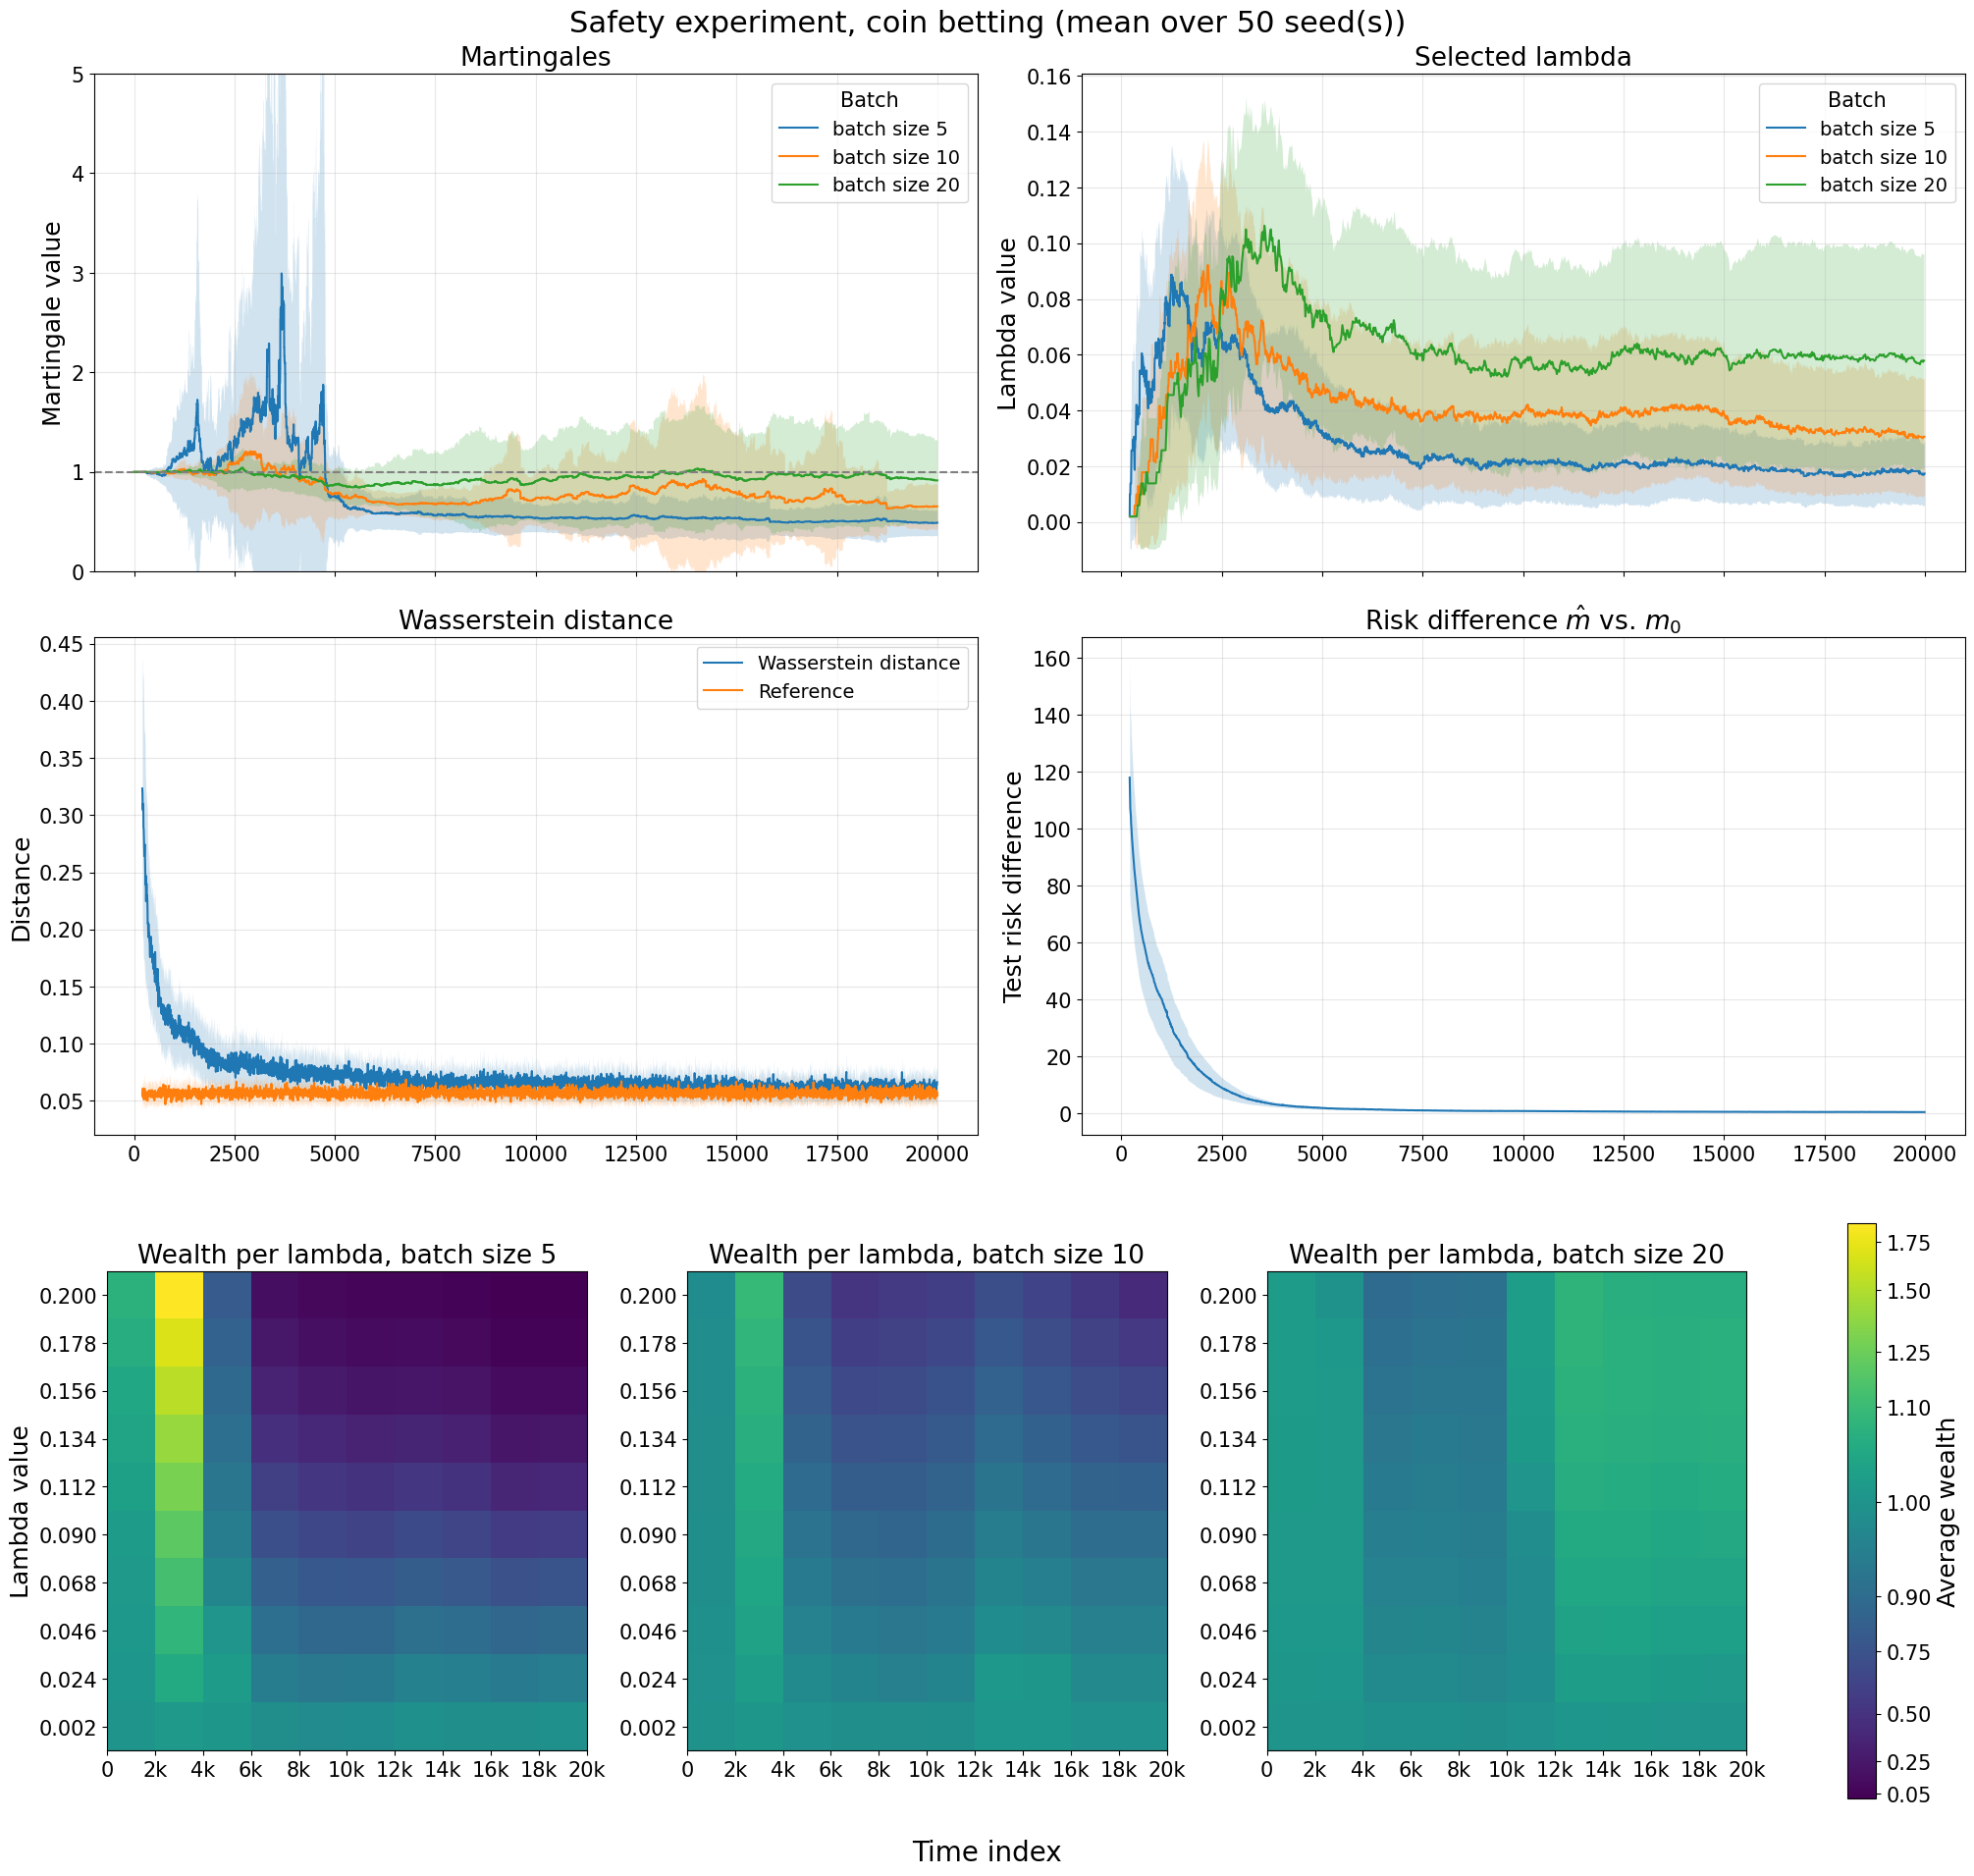

In [22]:
martingale_ylim = (0, 5)
full_edges = np.linspace(0, n, n_intervals + 1)


def wealth_heatmap_full(b):
    """Same as wealth_heatmap, with the intervals splitting [0, n] instead of [n_init, n]."""
    wealths = stack([runs[s][1][coordinate][b][strategy]["wealth_history"] for s in seeds])
    interval = np.digitize(update_times(wealths.shape[1], b), full_edges[1:-1])
    return np.stack([wealths[:, interval == k].mean(axis=(0, 1)) for k in range(n_intervals)], axis=1)


full_heatmaps = {b: wealth_heatmap_full(b) for b in batch_list}
full_vmin = min(np.nanmin(h) for h in full_heatmaps.values())
full_vmax = max(np.nanmax(h) for h in full_heatmaps.values())

with plt.rc_context({"font.size": 16, "axes.titlesize": 19, "axes.labelsize": 18,
                     "xtick.labelsize": 15, "ytick.labelsize": 15,
                     "legend.fontsize": 14, "legend.title_fontsize": 15}):
    fig = plt.figure(figsize=(20, 19), layout="constrained")
    top, bottom = fig.subfigures(2, 1, height_ratios=[2, 1.15])

    axes = top.subplots(2, 2, sharex=True)
    plot_martingales(axes[0, 0])
    plot_lambdas(axes[0, 1])
    plot_wasserstein(axes[1, 0])
    plot_risk_difference(axes[1, 1])
    axes[0, 0].axhline(1, color="gray", linestyle="--", linewidth=1.5)
    axes[0, 0].set_ylim(*martingale_ylim)
    for ax, title in zip(axes.flat, ["Martingales", "Selected lambda", "Wasserstein distance",
                                     r"Risk difference $\hat m$ vs. $m_0$"]):
        ax.set(title=title, xlabel="")

    heat_axes = bottom.subplots(1, len(batch_list))
    for ax, b in zip(heat_axes, batch_list):
        im = ax.imshow(full_heatmaps[b], origin="lower", cmap="viridis", norm=wealth_norm(full_vmin, full_vmax))
        ax.set_xticks(np.arange(n_intervals + 1) - 0.5, [f"{e / 1000:.0f}k" if e else "0" for e in full_edges])
        ax.set_yticks(range(len(lambda_values)), [f"{lam:.3f}" for lam in lambda_values])
        ax.set_title(f"Wealth per lambda, batch size {b}")
    heat_axes[0].set_ylabel("Lambda value")
    bottom.colorbar(im, ax=heat_axes, label="Average wealth", shrink=0.9,
                    ticks=colorbar_ticks(full_vmin, full_vmax))

    fig.supxlabel("Time index", fontsize=20)
    fig.suptitle(f"Safety experiment, {strategy.replace('_', ' ')} ({seeds_note()})", fontsize=22)
    fig.savefig(f"safety_full_summary_model{regressor_name}_{strategy}_n{n}.pdf", bbox_inches="tight")

## Appendix: original notebook cells (before the 2026-10-01 rewrite)

Paste any of these back into a code cell to restore the old single-seed behaviour.

**Original cell 0**

```python
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np


alpha = 0.05
n = 8000
regressor_name = "nn"
coordinate = 0
batch_list = [5, 10, 20]
smallest_batch = min(batch_list)
seed = 1
single_seed = False
strategy = "coin betting"



results_dir = Path("../results/csv/safety_simulations")
```

**Original cell 1**

```python
# filename = f"simulations_safety_model{regressor_name}_{seed}_seed_martingales.pkl"
# file = results_dir / filename
# with open(file, "rb") as f:
#     all_martingales = pickle.load(f)
```

**Original cell 2**

```python
file = f"/home/michele/Documents/testing_conditional_independence/shaer_replication/ecrt/results/csv/safety_simulations/simulations_safety_modelnn_1_seed_n_{n}_martingales.pkl"
with open(file, "rb") as f:
    all_martingales = pickle.load(f)
```

**Original cell 3**

```python
all_martingales[0]['coin betting']#[2][0]
```

**Original cell 4**

```python
martingales_by_batch = all_martingales[0]["coin betting"]
fig, ax = plt.subplots(figsize=(9, 5))
for batch in sorted(martingales_by_batch):
    values = np.asarray(martingales_by_batch[batch][coordinate])
    ax.plot(np.arange(values.size), values, label=f"batch size {batch}")

ax.set(title=f"Coin betting martingales (seed {seed}, feature {coordinate})",
       xlabel="Time index", ylabel="Martingale value")
ax.legend(title="Batch")
ax.grid(True, alpha=0.3)
plt.tight_layout()
```

**Original cell 5**

```python
#np.array(
lambdas = {}
for b in batch_list:
    lambdas[b] = [d["lambda"]/5.0 for d in all_martingales[1][0][b]['coin betting']]
```

**Original cell 6**

```python
fig, ax = plt.subplots(figsize=(9, 5))
for batch in batch_list:
    values = np.asarray(lambdas[batch])
    ax.plot(np.arange(values.size) * batch, values, label=f"batch size {batch}")

ax.set(title=f"Selected lambda by batch (seed {seed}, feature {coordinate})",
       xlabel="Time index (i × batch size)", ylabel="Lambda value")
ax.legend(title="Batch")
ax.grid(True, alpha=0.3)
plt.tight_layout()
```

**Original cell 7**

```python
def load_martingales():
    files = []
    if single_seed:
        file = results_dir / f"simulations_safety_model{regressor_name}_{seed}_seed_martingales.pkl"
        files.append(file)
        if not file.exists():
            raise FileNotFoundError(f"No martingale file found  in {results_dir}")
    else:
        files = sorted(
            results_dir.glob(
                f"simulations_safety_model{regressor_name}_*_seed_martingales.pkl"
            )
        )
        if not files:
            raise FileNotFoundError(f"No martingale files found  in {results_dir}")

    all_martingales = []
    for file in files:
        with open(file, "rb") as f:
            all_martingales.append(pickle.load(f))


    mean_martingales = {}
    for batch in all_martingales[0][strategy]:
        mean_martingales[batch] = {}
        for j in all_martingales[0][strategy][batch]:
            arrays = [m[strategy][batch][j] for m in all_martingales]
            mean_martingales[strategy][batch][j] = np.mean(arrays, axis=0)

    print(f"loaded {len(all_martingales)} seeds")
    return mean_martingales
```

**Original cell 8**

```python
all_martingales[2]
```

**Original cell 9**

```python
print(len(all_martingales[2]))
print(len(lambdas[5]))
print(len(lambdas[10]))
```

**Original cell 10**

```python
all_martingales[2]
```

**Original cell 11**

```python
plt.figure(figsize=(9, 4))

was = [p[0] for p in all_martingales[2]]
ref = [p[1] for p in all_martingales[2]]

plt.plot(np.arange(len(was)) * smallest_batch, was, label=f"Wasserstein distance")
plt.plot(np.arange(len(ref)) * smallest_batch, ref, label=f"Reference")

plt.legend(title="Batch size")
plt.title("all_martingales[2]")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
```

**Original cell 12**

```python
print(len(lambdas[5]))
print(len(all_martingales[2]))
```

**Original cell 13**

```python
all_martingales[3]
```

**Original cell 14**

```python
plt.figure(figsize=(9, 4))

seq = all_martingales[3]

plt.plot(np.arange(len(seq)) * smallest_batch, seq, label=f"Risk difference ")

plt.legend(title="Batch size")
plt.title("Risk difference m_hat vs. m_0")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
```